# TQrouting — Quick Start

Solve your first vehicle routing problem in five minutes.

```bash
pip install -r requirements.txt          # tqrouting, jupyter, matplotlib (see README.md)
export TQROUTING_LICENSE_KEY="key/..."   # your license key
```

This notebook builds a small capacitated VRP (CVRP), solves it, and plots the routes.
When you're done, pick the notebook for your use case:

| Notebook | What's inside |
|---|---|
| [constraints.ipynb](constraints.ipynb) | Time windows, capacities (1-D and 2-D), route limits, shifts, pickup & delivery, multi-trip reloads, heterogeneous fleets, multiple depots |
| [objectives.ipynb](objectives.ipynb) | Duration/distance trade-off, prize-collecting, fixed vehicle costs, waiting-time pricing, soft constraints |
| [real_world_osrm.ipynb](real_world_osrm.ipynb) | GPS coordinates, road-network matrices via OSRM (local Docker or remote), map plots |
| [workflow.ipynb](workflow.ipynb) | JSON round-trips, time formats, schedules & departure times, infeasibility and warnings |

Full documentation: see the link in the repository [README](README.md).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from tqrouting import TQRouter, VRPInstance, Customer, VehicleType, Location, TimeWindow
from tqrouting.matrix import EuclideanMatrixProvider

data_dir = Path("data")

# Uses the TQROUTING_LICENSE_KEY environment variable by default.
# Set it before running: export TQROUTING_LICENSE_KEY="key/..."
router = TQRouter()

## 1. Build a CVRP instance

Ten customers with delivery demands, one depot, three trucks of capacity 30.
Locations use x/y coordinates; a Euclidean provider fills the duration matrix.

In [2]:
instance = VRPInstance(
    customers=[
        Customer(id="C0", location=Location(x=20, y=35), delivery_load=9),
        Customer(id="C1", location=Location(x=42, y=18), delivery_load=4),
        Customer(id="C2", location=Location(x=55, y=60), delivery_load=7),
        Customer(id="C3", location=Location(x=10, y=50), delivery_load=12),
        Customer(id="C4", location=Location(x=65, y=30), delivery_load=5),
        Customer(id="C5", location=Location(x=30, y=70), delivery_load=8),
        Customer(id="C6", location=Location(x=75, y=55), delivery_load=6),
        Customer(id="C7", location=Location(x=48, y=42), delivery_load=11),
        Customer(id="C8", location=Location(x=15, y=15), delivery_load=3),
        Customer(id="C9", location=Location(x=60, y=10), delivery_load=10),
    ],
    fleet=[
        VehicleType(
            id="truck",
            start_location=Location(x=40, y=40),
            end_location=Location(x=40, y=40),
            capacity_load=30,
            n_vehicles=3,
        ),
    ],
)
instance.compute_duration_matrix(EuclideanMatrixProvider())
print(f"{len(instance.customers)} customers, matrix {len(instance.duration_matrix)}x{len(instance.duration_matrix)}")

[tqrouting] Computing duration matrix for 11 unique locations...


[tqrouting] Duration matrix ready (11×11, 0.0s).


10 customers, matrix 11x11


## 2. Solve

In [3]:
solution = router.solve(instance, time_limit=3)

print(f"Status: {solution.solution_status}")
print(f"Total route duration: {solution.total_route_duration:.1f}")
print(f"Routes: {len(solution.routes)}, visits: {solution.total_n_visits}")

[tqrouting] Solving VRP instance (10 customers, 1 vehicle types)...


[tqrouting] Solver finished in 3.0s (status=Feasible, 3 routes, duration 312.1, 0 unvisited).


Status: Feasible
Total route duration: 312.1
Routes: 3, visits: 10


## 3. Inspect routes

In [4]:
for route in solution.routes:
    customer_ids = [v.customer_id for v in route.customer_sequence]
    print(
        f"Route {route.id} | duration: {route.route_duration:.1f} | "
        f"load: {route.route_delivery_load:.0f} | customers: {customer_ids}"
    )

Route 0 | duration: 98.6 | load: 29 | customers: ['C0', 'C3', 'C5']
Route 1 | duration: 83.8 | load: 24 | customers: ['C2', 'C6', 'C7']
Route 2 | duration: 129.8 | load: 22 | customers: ['C4', 'C9', 'C1', 'C8']


## 4. Visualize

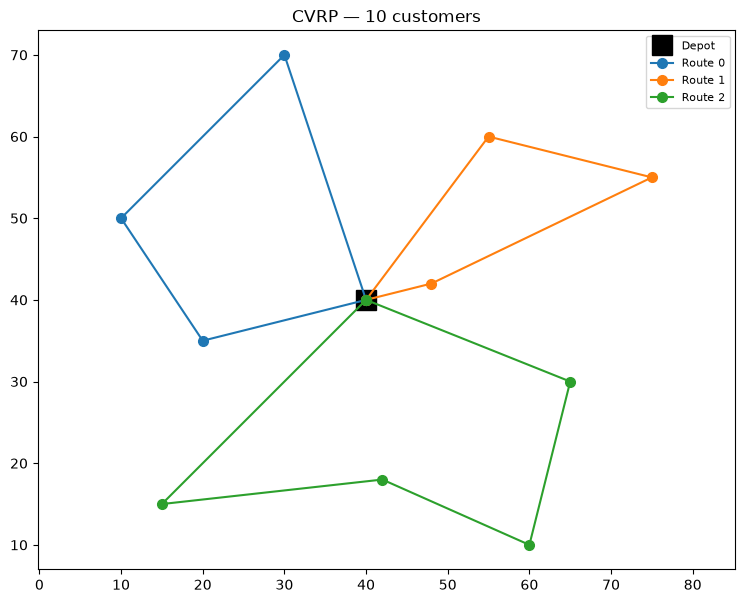

In [5]:
def plot_solution(instance: VRPInstance, solution, title="VRP Solution"):
    """Plot routes on a 2D plane using customer x/y coordinates."""
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    id_to_loc = {}
    for i, c in enumerate(instance.customers):
        cid = c.id if c.id is not None else i
        id_to_loc[cid] = c.location

    depot = instance.fleet[0].start_location
    ax.plot(depot.x, depot.y, "ks", markersize=14, label="Depot")

    for route in solution.routes:
        color = colors[route.id % len(colors)]
        xs, ys = [depot.x], [depot.y]
        for visit in route.customer_sequence:
            loc = id_to_loc[visit.customer_id]
            xs.append(loc.x)
            ys.append(loc.y)
        xs.append(depot.x)
        ys.append(depot.y)
        ax.plot(xs, ys, "o-", color=color, markersize=7, label=f"Route {route.id}")

    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")
    plt.show()

plot_solution(instance, solution, title="CVRP — 10 customers")

## Where to go next

- **Constraints** (time windows, capacities, reloads, fleets): [constraints.ipynb](constraints.ipynb)
- **Objectives** (distance pricing, prizes, vehicle costs): [objectives.ipynb](objectives.ipynb)
- **Real road networks** (GPS + OSRM): [real_world_osrm.ipynb](real_world_osrm.ipynb)
- **Workflow** (JSON, schedules, warnings): [workflow.ipynb](workflow.ipynb)